In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

PLOT_STYLE = {
    "font.size": 22,
    "axes.titlesize": 24,
    "axes.labelsize": 22,
    "axes.titlepad": 12,
    "xtick.labelsize": 22,
    "ytick.labelsize": 22,
    "legend.fontsize": 22,
    "legend.title_fontsize": 22,
    "figure.titlesize": 24,
}


def apply_plot_style():
    plt.style.use("seaborn-v0_8-whitegrid")
    plt.rcParams.update(PLOT_STYLE)


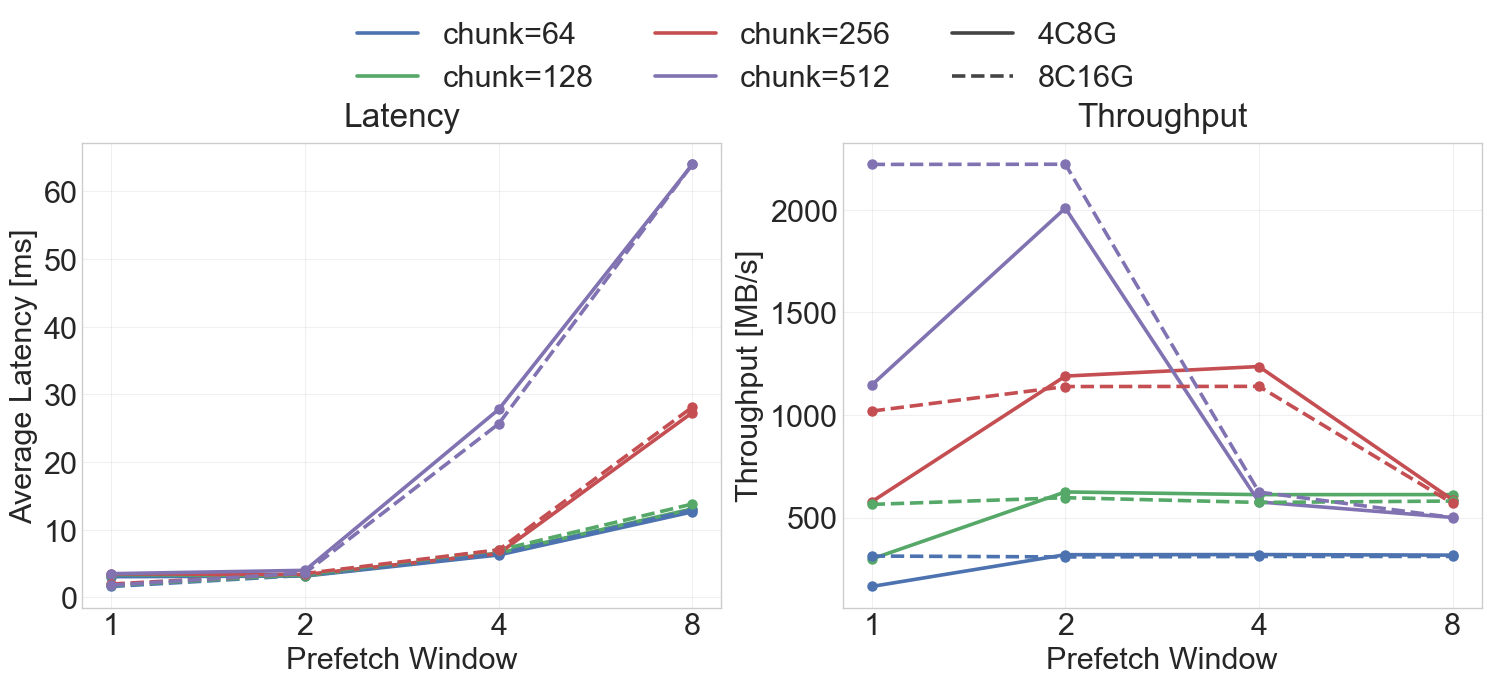

Saved figure to /Users/sunweber/workspace/dist_learn/KVTensor/evaluation/figures/kv_calibration_621.pdf


In [2]:
# Section 6.2.1: sequential KV-read calibration
from matplotlib.lines import Line2D

apply_plot_style()


def find_repo_root() -> Path:
    for root in (Path.cwd(), *Path.cwd().parents):
        if (root / "cpp" / "microbench" / "out").exists():
            return root
    raise FileNotFoundError("Could not locate the repository root from the current working directory.")


repo_root = find_repo_root()

kv_paths = {
    "4c8g": repo_root / "cpp" / "microbench" / "out" / "8b" / "4c8g" / "kv_results.csv",
    "8c16g": repo_root / "cpp" / "microbench" / "out" / "8b" / "8c16g" / "kv_results.csv",
}

platform_frames = []
for platform, csv_path in kv_paths.items():
    frame = pd.read_csv(csv_path).copy()
    frame["platform"] = platform
    frame = frame.rename(columns={"chunk_size_param": "chunk_size"})
    platform_frames.append(frame[["platform", "chunk_size", "window_chunks", "avg_ms", "throughput_mb_s"]])

kv_621 = pd.concat(platform_frames, ignore_index=True)
kv_621 = kv_621.sort_values(["platform", "chunk_size", "window_chunks"])

chunk_order = sorted(kv_621["chunk_size"].unique())
window_order = sorted(kv_621["window_chunks"].unique())
x_positions = list(range(len(window_order)))
window_position_map = dict(zip(window_order, x_positions))
chunk_colors = {64: "#4C72B0", 128: "#55A868", 256: "#C44E52", 512: "#8172B2"}
platform_styles = {"4c8g": "-", "8c16g": "--"}
platform_labels = {"4c8g": "4C8G", "8c16g": "8C16G"}

fig, axes = plt.subplots(1, 2, figsize=(14.8, 5.8), sharex=True, constrained_layout=True)

for platform in ["4c8g", "8c16g"]:
    platform_df = kv_621[kv_621["platform"] == platform]
    for chunk_size in chunk_order:
        line_df = platform_df[platform_df["chunk_size"] == chunk_size].sort_values("window_chunks")
        line_x = [window_position_map[int(window)] for window in line_df["window_chunks"]]
        axes[0].plot(
            line_x,
            line_df["avg_ms"],
            color=chunk_colors[chunk_size],
            linestyle=platform_styles[platform],
            marker="o",
            linewidth=2.6,
            markersize=6.5,
        )
        axes[1].plot(
            line_x,
            line_df["throughput_mb_s"],
            color=chunk_colors[chunk_size],
            linestyle=platform_styles[platform],
            marker="o",
            linewidth=2.6,
            markersize=6.5,
        )

axes[0].set_title("Latency")
axes[0].set_xlabel("Prefetch Window")
axes[0].set_ylabel("Average Latency [ms]")
axes[0].set_xticks(x_positions)
axes[0].set_xticklabels([str(window) for window in window_order])

axes[1].set_title("Throughput")
axes[1].set_xlabel("Prefetch Window")
axes[1].set_ylabel("Throughput [MB/s]")
axes[1].set_xticks(x_positions)
axes[1].set_xticklabels([str(window) for window in window_order])

for ax in axes:
    ax.grid(axis="both", alpha=0.28)
    ax.set_axisbelow(True)

chunk_handles = [
    Line2D([0], [0], color=chunk_colors[chunk_size], linewidth=2.6, label=f"chunk={chunk_size}")
    for chunk_size in chunk_order
]
platform_handles = [
    Line2D([0], [0], color="#444444", linestyle=platform_styles[platform], linewidth=2.6, label=platform_labels[platform])
    for platform in ["4c8g", "8c16g"]
]
fig.legend(
    chunk_handles + platform_handles,
    [handle.get_label() for handle in chunk_handles + platform_handles],
    loc="upper center",
    ncol=3,
    frameon=False,
    bbox_to_anchor=(0.5, 1.18),
)

output_dir = repo_root / "evaluation" / "figures"
output_dir.mkdir(parents=True, exist_ok=True)
pdf_path = output_dir / "kv_calibration_621.pdf"
plt.savefig(pdf_path, bbox_inches="tight")
plt.show()
print(f"Saved figure to {pdf_path}")


In [4]:
# Section 6.2.2: compute calibration
if "repo_root" not in globals():
    repo_root = find_repo_root()

calibration_data_root = repo_root / "evaluation" / "calibration_fixed"


In [21]:
compute_622 = pd.read_csv(calibration_data_root / "compute_calibration_622.csv")

compute_622.style.hide(axis="index")


Phase,Kernel,"Shape (m, k, n)",4c8g [GFLOP/s],8c16g [GFLOP/s]
Decode,GEMV,"(1, 4096, 4096)",14.750000,34.420000
Decode,GEMV,"(1, 4096, 11008)",12.720000,25.930000
Decode,GEMV,"(1, 14336, 4096)",15.330000,20.370000
Prefill,GEMM,"(64, 4096, 4096)",458.870000,1128.010000
Prefill,GEMM,"(64, 4096, 11008)",494.640000,879.400000
Prefill,GEMM,"(64, 14336, 4096)",660.120000,1352.690000


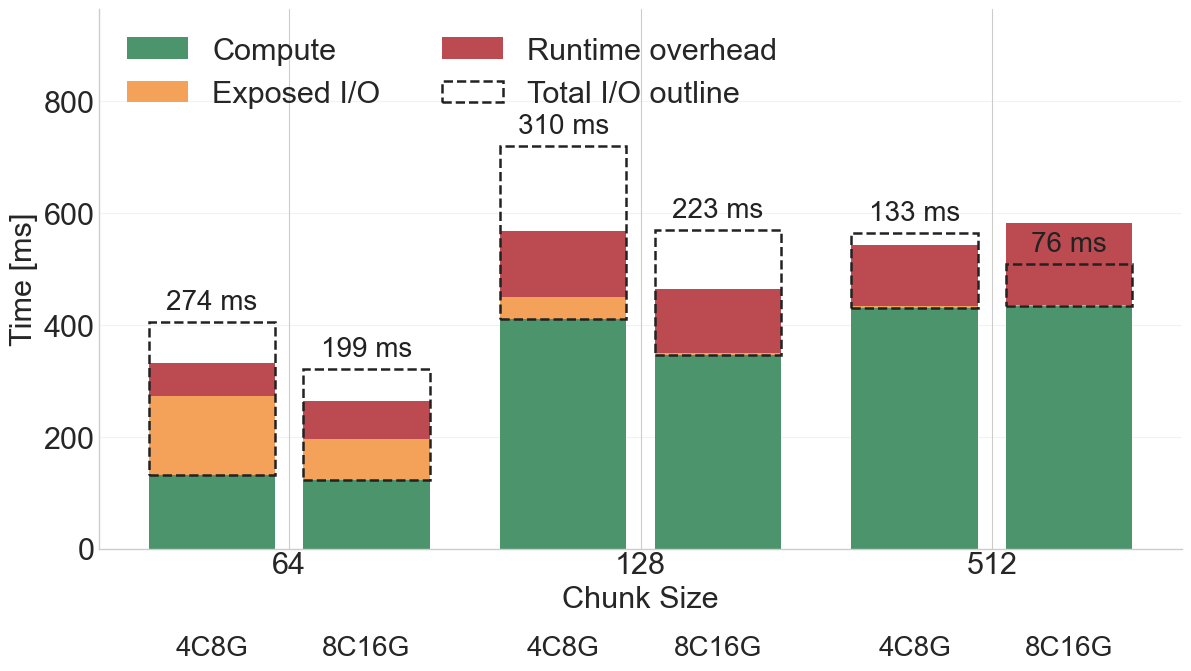

In [40]:
# Section 6.2.3: runtime calibration for exposed I/O and overhead
apply_plot_style()

runtime_623 = pd.read_csv(calibration_data_root / "runtime_calibration_623.csv")
runtime_623 = runtime_623.sort_values(["chunk_size", "platform"])

chunk_sizes = [64, 128, 512]
platforms = ["4c8g", "8c16g"]
component_colors = {
    "compute_ms": "#4c956c",
    "io_exposed_ms": "#f4a259",
    "runtime_overhead_ms": "#bc4b51",
}
bar_width = 0.36
platform_offsets = {"4c8g": -0.22, "8c16g": 0.22}

fig, ax = plt.subplots(figsize=(11.8, 6.6), constrained_layout=True)

for platform in platforms:
    platform_df = runtime_623[runtime_623["platform"] == platform].set_index("chunk_size").loc[chunk_sizes]
    x_positions = [idx + platform_offsets[platform] for idx in range(len(chunk_sizes))]

    ax.bar(
        x_positions,
        platform_df["compute_ms"],
        width=bar_width,
        color=component_colors["compute_ms"],
        label="Compute" if platform == platforms[0] else "_nolegend_",
    )
    ax.bar(
        x_positions,
        platform_df["io_exposed_ms"],
        width=bar_width,
        bottom=platform_df["compute_ms"],
        color=component_colors["io_exposed_ms"],
        label="Exposed I/O" if platform == platforms[0] else "_nolegend_",
    )
    ax.bar(
        x_positions,
        platform_df["runtime_overhead_ms"],
        width=bar_width,
        bottom=platform_df["compute_ms"] + platform_df["io_exposed_ms"],
        color=component_colors["runtime_overhead_ms"],
        label="Runtime overhead" if platform == platforms[0] else "_nolegend_",
    )
    ax.bar(
        x_positions,
        platform_df["io_total_ms"],
        width=bar_width,
        bottom=platform_df["compute_ms"],
        fill=False,
        edgecolor="#222222",
        linewidth=1.8,
        linestyle="--",
        label="Total I/O outline" if platform == platforms[0] else "_nolegend_",
    )

    for x_pos, io_total, compute_ms in zip(
        x_positions,
        platform_df["io_total_ms"],
        platform_df["compute_ms"],
    ):
        ax.text(
            x_pos,
            compute_ms + io_total + 12,
            f"{io_total:.0f} ms",
            ha="center",
            va="bottom",
            fontsize=20,
            color="#222222",
        )
        ax.text(
            x_pos,
            -0.16,
            platform.upper(),
            transform=ax.get_xaxis_transform(),
            ha="center",
            va="top",
            fontsize=20,
            clip_on=False,
        )

ax.set_xticks(range(len(chunk_sizes)))
ax.set_xticklabels(chunk_sizes)
ax.set_xlabel("Chunk Size")
ax.set_ylabel("Time [ms]")
ax.set_ylim(0, float((runtime_623["compute_ms"] + runtime_623["io_total_ms"]).max()) * 1.34)
ax.legend(ncol=2, frameon=False, loc="upper left")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="y", alpha=0.25)
ax.set_axisbelow(True)
ax.tick_params(axis="x", pad=2)
plt.savefig(repo_root / "evaluation" / "figures" / "runtime_decomposition_623.pdf", bbox_inches="tight")
plt.show()


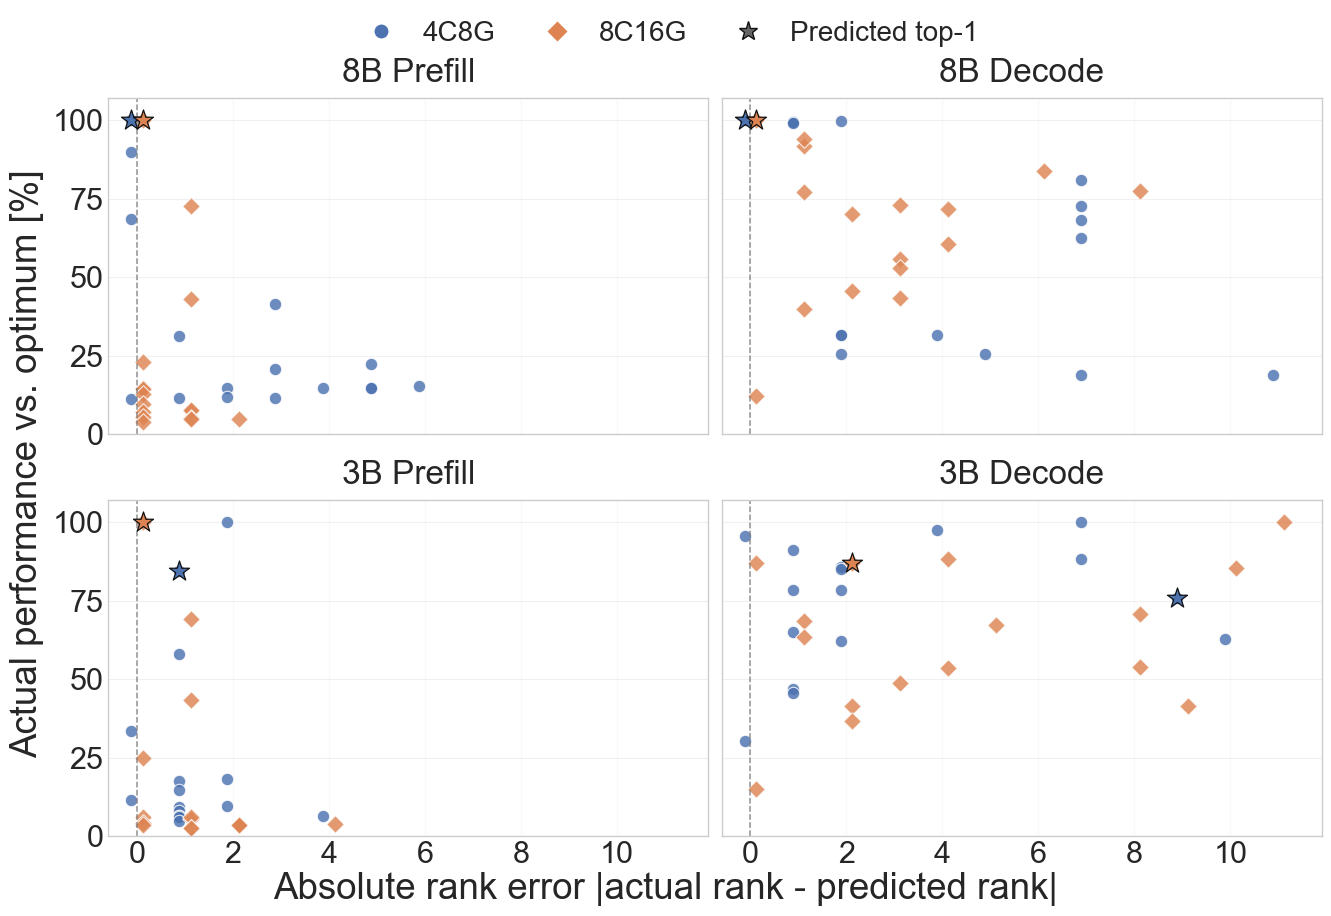

Saved figure to /Users/sunweber/workspace/dist_learn/KVTensor/evaluation/figures/validation_625.pdf


In [13]:
# Section 6.2.5: rank-gap versus performance-gap validation
from matplotlib.lines import Line2D

apply_plot_style()

model_order = ["8b", "3b"]
mode_order = ["prefill", "decode"]
model_labels = {"8b": "8B", "3b": "3B"}
mode_labels = {"prefill": "Prefill", "decode": "Decode"}
platform_order = ["4c8g", "8c16g"]
platform_labels = {"4c8g": "4C8G", "8c16g": "8C16G"}
platform_colors = {"4c8g": "#4C72B0", "8c16g": "#DD8452"}
platform_markers = {"4c8g": "o", "8c16g": "D"}
platform_offsets = {"4c8g": -0.12, "8c16g": 0.12}

validation_625 = pd.read_csv(calibration_data_root / "validation_625_cases.csv")
summary_625 = pd.read_csv(calibration_data_root / "validation_625_summary.csv")

validation_625["actual_perf_vs_optimum_pct"] = 100.0 / (1.0 + validation_625["actual_slowdown_pct"] / 100.0)

max_rank_error = int(validation_625["rank_gap"].max())
rank_ticks = list(range(0, max_rank_error + 1, 2))
panel_specs = [(model_size, mode) for model_size in model_order for mode in mode_order]

legend_handles = [
    Line2D([0], [0], marker=platform_markers[platform], color="w", markerfacecolor=platform_colors[platform], markeredgecolor="white", markersize=11, linewidth=0, label=platform_labels[platform])
    for platform in platform_order
] + [
    Line2D([0], [0], marker="*", color="w", markerfacecolor="#666666", markeredgecolor="#111111", markersize=14, linewidth=0, label="Predicted top-1")
]

fig, axes = plt.subplots(2, 2, figsize=(13.2, 8.2), sharex=True, sharey=True, constrained_layout=True)
axes = axes.flatten()

for ax, (model_size, mode) in zip(axes, panel_specs):
    for platform in platform_order:
        plot_df = validation_625[
            (validation_625["model_size"] == model_size)
            & (validation_625["platform"] == platform)
            & (validation_625["mode"] == mode)
        ].copy()
        summary_625[
            (summary_625["model_size"] == model_size)
            & (summary_625["platform"] == platform)
            & (summary_625["mode"] == mode)
        ].iloc[0]

        ax.scatter(
            plot_df["rank_gap"] + platform_offsets[platform],
            plot_df["actual_perf_vs_optimum_pct"],
            s=80,
            color=platform_colors[platform],
            marker=platform_markers[platform],
            alpha=0.82,
            edgecolor="white",
            linewidth=0.8,
        )

        top1_point = plot_df.loc[plot_df["predicted_rank"] == 1].iloc[0]
        ax.scatter(
            [float(top1_point["rank_gap"]) + platform_offsets[platform]],
            [float(top1_point["actual_perf_vs_optimum_pct"])],
            s=230,
            marker="*",
            color=platform_colors[platform],
            edgecolor="#111111",
            linewidth=0.9,
            zorder=5,
        )

    ax.axvline(0.0, linestyle="--", color="#777777", linewidth=1.1, alpha=0.8)
    ax.set_title(f"{model_labels[model_size]} {mode_labels[mode]}")
    ax.set_xlim(-0.6, max_rank_error + 0.9)
    ax.set_ylim(0.0, 107.0)
    ax.set_xticks(rank_ticks)
    ax.set_yticks([0, 25, 50, 75, 100])
    ax.grid(axis="y", which="both", alpha=0.28)
    ax.grid(axis="x", alpha=0.12)
    ax.set_axisbelow(True)

fig.legend(
    handles=legend_handles,
    loc="upper center",
    ncol=3,
    frameon=False,
    bbox_to_anchor=(0.5, 1.07),
    fontsize=20,
    handletextpad=0.5,
    columnspacing=1.2,
)
fig.supxlabel("Absolute rank error |actual rank - predicted rank|", y=-0.04)
fig.supylabel("Actual performance vs. optimum [%]")

output_dir = repo_root / "evaluation" / "figures"
output_dir.mkdir(parents=True, exist_ok=True)
pdf_path = output_dir / "validation_625.pdf"
plt.savefig(pdf_path, bbox_inches="tight")
plt.show()
print(f"Saved figure to {pdf_path}")


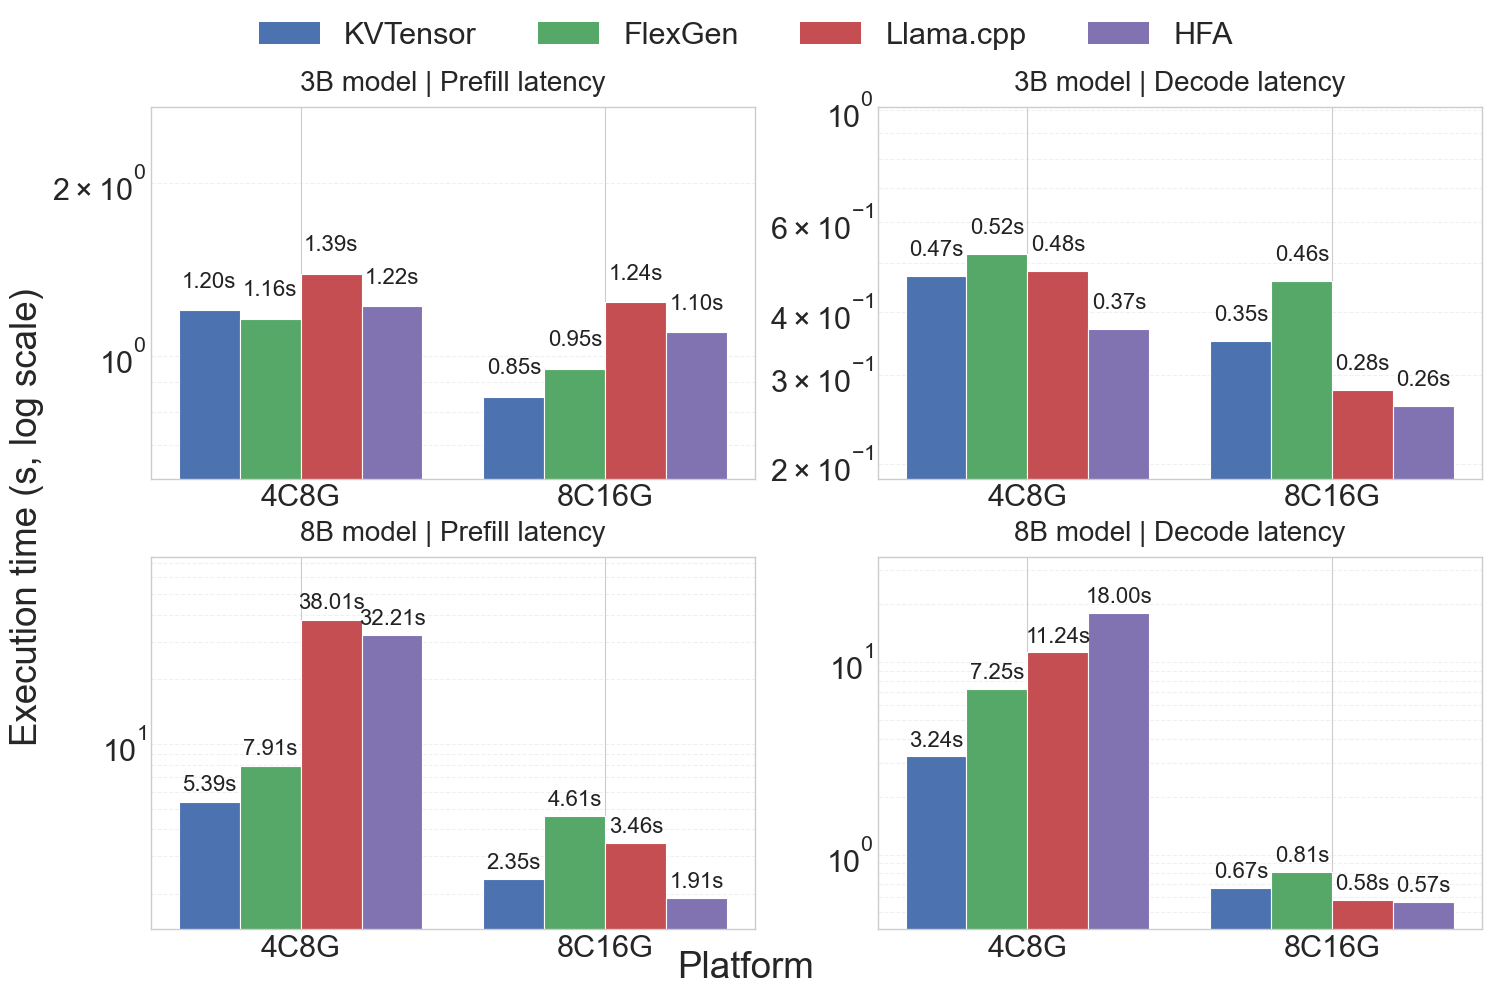

Saved figure to /Users/sunweber/workspace/dist_learn/KVTensor/evaluation/figures/section63_figure1.pdf


In [21]:
# Section 6.3.1: baseline comparison figure
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

apply_plot_style()

if "repo_root" not in globals():
    def find_repo_root() -> Path:
        for root in (Path.cwd(), *Path.cwd().parents):
            if (root / "evaluation" / "section63_figure1.csv").exists():
                return root
        raise FileNotFoundError("Could not locate the repository root from the current working directory.")

    repo_root = find_repo_root()

baseline_df = pd.read_csv(repo_root / "evaluation" / "section63_figure1.csv")
baseline_df["model"] = baseline_df["model"].str.lower()

model_order = ["3b", "8b"]
model_labels = {"3b": "3B model", "8b": "8B model"}
platform_order = ["4c8g", "8c16g"]
platform_labels = {"4c8g": "4C8G", "8c16g": "8C16G"}
system_order = ["KVTensor", "FlexGen", "Llama.cpp", "HFA"]
system_colors = {
    "KVTensor": "#4C72B0",
    "FlexGen": "#55A868",
    "Llama.cpp": "#C44E52",
    "HFA": "#8172B2",
}
metric_specs = [
    ("prefill_s", "Prefill latency"),
    ("decode_s", "Decode latency"),
]

x_positions = list(range(len(platform_order)))
width = 0.20
offsets = [-1.5 * width, -0.5 * width, 0.5 * width, 1.5 * width]


def annotate_bars(ax, bars):
    for bar in bars:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height * 1.08,
            f"{height:.2f}s",
            ha="center",
            va="bottom",
            rotation=0,
            fontsize=16,
            color="#222222",
            clip_on=False,
        )


def plot_runtime_panel(ax, panel_df, metric, title):
    for offset, system in zip(offsets, system_order):
        system_df = panel_df.loc[panel_df["system"] == system].set_index("platform")
        xs = []
        ys = []
        for x, platform in zip(x_positions, platform_order):
            if platform in system_df.index:
                xs.append(x + offset)
                ys.append(float(system_df.at[platform, metric]))
        bars = ax.bar(
            xs,
            ys,
            width=width,
            color=system_colors[system],
            edgecolor="white",
            linewidth=0.8,
        )
        annotate_bars(ax, bars)

    values = panel_df[metric]
    ax.set_yscale("log")
    ax.set_ylim(values.min() * 0.72, values.max() * 1.95)
    ax.set_xticks(x_positions)
    ax.set_xticklabels([platform_labels[p] for p in platform_order])
    ax.set_title(title, fontsize=20)
    ax.grid(axis="y", which="both", linestyle="--", alpha=0.28)
    ax.set_axisbelow(True)

fig, axes = plt.subplots(2, 2, figsize=(14.8, 9.0), constrained_layout=True)

for row_idx, model in enumerate(model_order):
    model_df = baseline_df.loc[baseline_df["model"] == model].copy()
    for col_idx, (metric, metric_title) in enumerate(metric_specs):
        ax = axes[row_idx, col_idx]
        plot_runtime_panel(ax, model_df, metric, f"{model_labels[model]} | {metric_title}")


legend_handles = [Patch(facecolor=system_colors[system], label=system) for system in system_order]
fig.legend(
    legend_handles,
    [handle.get_label() for handle in legend_handles],
    loc="upper center",
    ncol=len(legend_handles),
    frameon=False,
    bbox_to_anchor=(0.5, 1.08),
)
fig.supxlabel("Platform", y=-0.02)
fig.supylabel("Execution time (s, log scale)")
output_dir = repo_root / "evaluation" / "figures"
output_dir.mkdir(parents=True, exist_ok=True)
pdf_path = output_dir / "section63_figure1.pdf"
fig.savefig(pdf_path, bbox_inches="tight")
plt.show()
print(f"Saved figure to {pdf_path}")


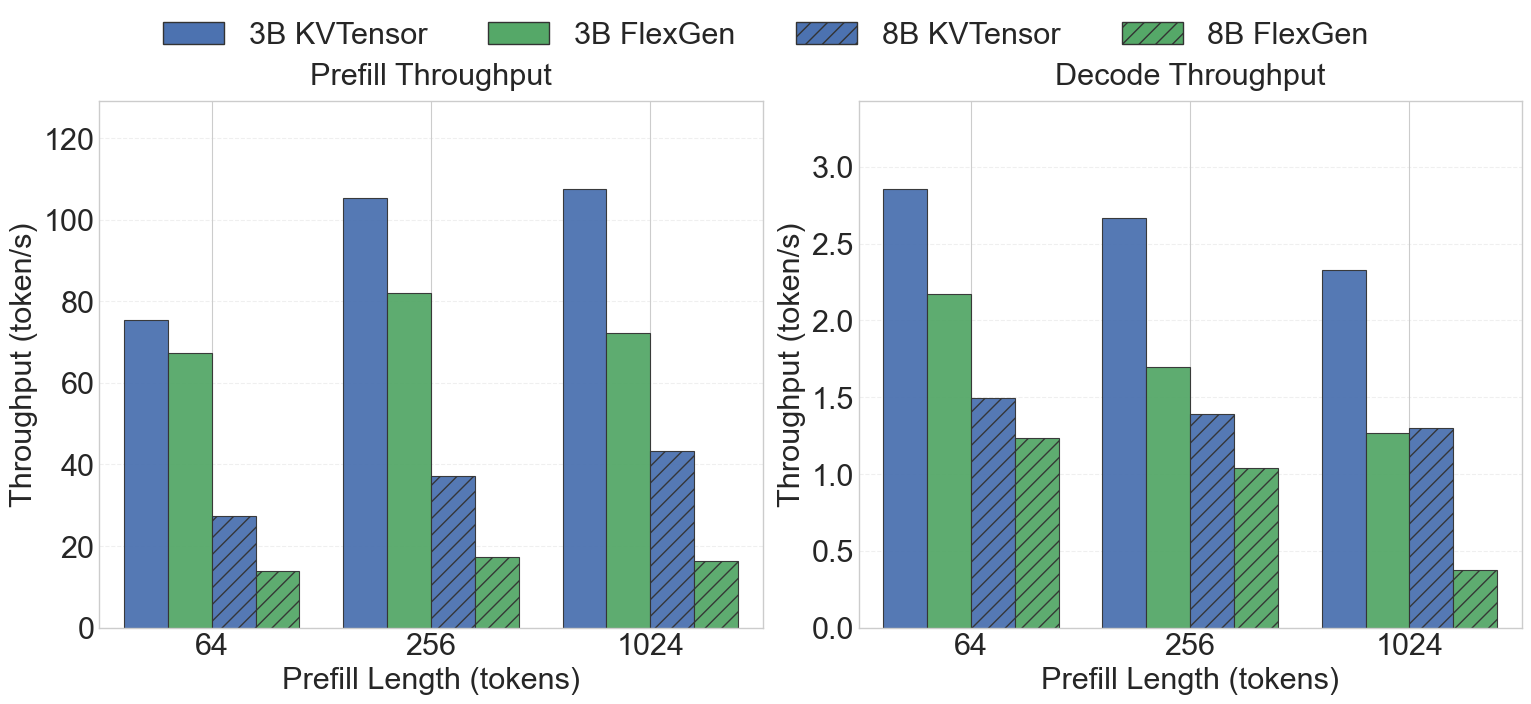

Saved figure to /Users/sunweber/workspace/dist_learn/KVTensor/evaluation/figures/section63_prefill_decode_error.pdf


In [26]:
# Section 6.3.1: prefill-length sensitivity for KVTensor and FlexGen
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

apply_plot_style()

if "repo_root" not in globals():
    def find_repo_root() -> Path:
        for root in (Path.cwd(), *Path.cwd().parents):
            if (root / "evaluation" / "prefill_decode_error.csv").exists():
                return root
        raise FileNotFoundError("Could not locate the repository root from the current working directory.")

    repo_root = find_repo_root()

length_df = pd.read_csv(repo_root / "evaluation" / "prefill_decode_error.csv")
length_df["model"] = length_df["model"].str.lower()
length_df["prefill_token_per_s"] = length_df["token_len"] / length_df["prefill_s"]
length_df["decode_token_per_s"] = 1.0 / length_df["decode_s"]
length_df = length_df.sort_values(["token_len", "model", "system"])

model_labels = {"3b": "3B", "8b": "8B"}
model_hatches = {"3b": "", "8b": "//"}
system_colors = {"KVTensor": "#4C72B0", "FlexGen": "#55A868"}
bar_specs = [
    ("3b", "KVTensor"),
    ("3b", "FlexGen"),
    ("8b", "KVTensor"),
    ("8b", "FlexGen"),
]
metric_specs = [
    ("prefill_token_per_s", "Prefill Throughput"),
    ("decode_token_per_s", "Decode Throughput"),
]
token_order = sorted(length_df["token_len"].unique())
x_positions = np.arange(len(token_order), dtype=float)
bar_width = 0.20
offsets = np.array([-1.5, -0.5, 0.5, 1.5]) * bar_width

fig, axes = plt.subplots(1, 2, figsize=(15.2, 6.4), constrained_layout=True, sharex=True)

for ax, (metric, metric_title) in zip(axes, metric_specs):
    panel_max = float(length_df[metric].max())

    for offset, (model, system) in zip(offsets, bar_specs):
        subset = (
            length_df.loc[(length_df["model"] == model) & (length_df["system"] == system)]
            .set_index("token_len")
            .reindex(token_order)
        )
        values = subset[metric].to_numpy(dtype=float)
        ax.bar(
            x_positions + offset,
            values,
            width=bar_width,
            color=system_colors[system],
            hatch=model_hatches[model],
            edgecolor="#333333",
            linewidth=0.8,
            alpha=0.95,
            label=f"{model_labels[model]} {system}",
        )

    ax.set_title(metric_title, fontsize=22)
    ax.set_xlabel("Prefill Length (tokens)")
    ax.set_ylabel("Throughput (token/s)")
    ax.set_xticks(x_positions)
    ax.set_xticklabels([str(token_len) for token_len in token_order])
    ax.set_ylim(0, panel_max * 1.20)
    ax.margins(x=0.04)
    ax.grid(axis="y", linestyle="--", alpha=0.3)
    ax.set_axisbelow(True)

legend_handles = [
    Patch(
        facecolor=system_colors[system],
        hatch=model_hatches[model],
        edgecolor="#333333",
        label=f"{model_labels[model]} {system}",
    )
    for model, system in bar_specs
]
fig.legend(
    legend_handles,
    [handle.get_label() for handle in legend_handles],
    loc="upper center",
    ncol=4,
    frameon=False,
    bbox_to_anchor=(0.5, 1.1),
)

output_dir = repo_root / "evaluation" / "figures"
output_dir.mkdir(parents=True, exist_ok=True)
pdf_path = output_dir / "section63_prefill_decode_error.pdf"
fig.savefig(pdf_path, bbox_inches="tight")
plt.show()
print(f"Saved figure to {pdf_path}")


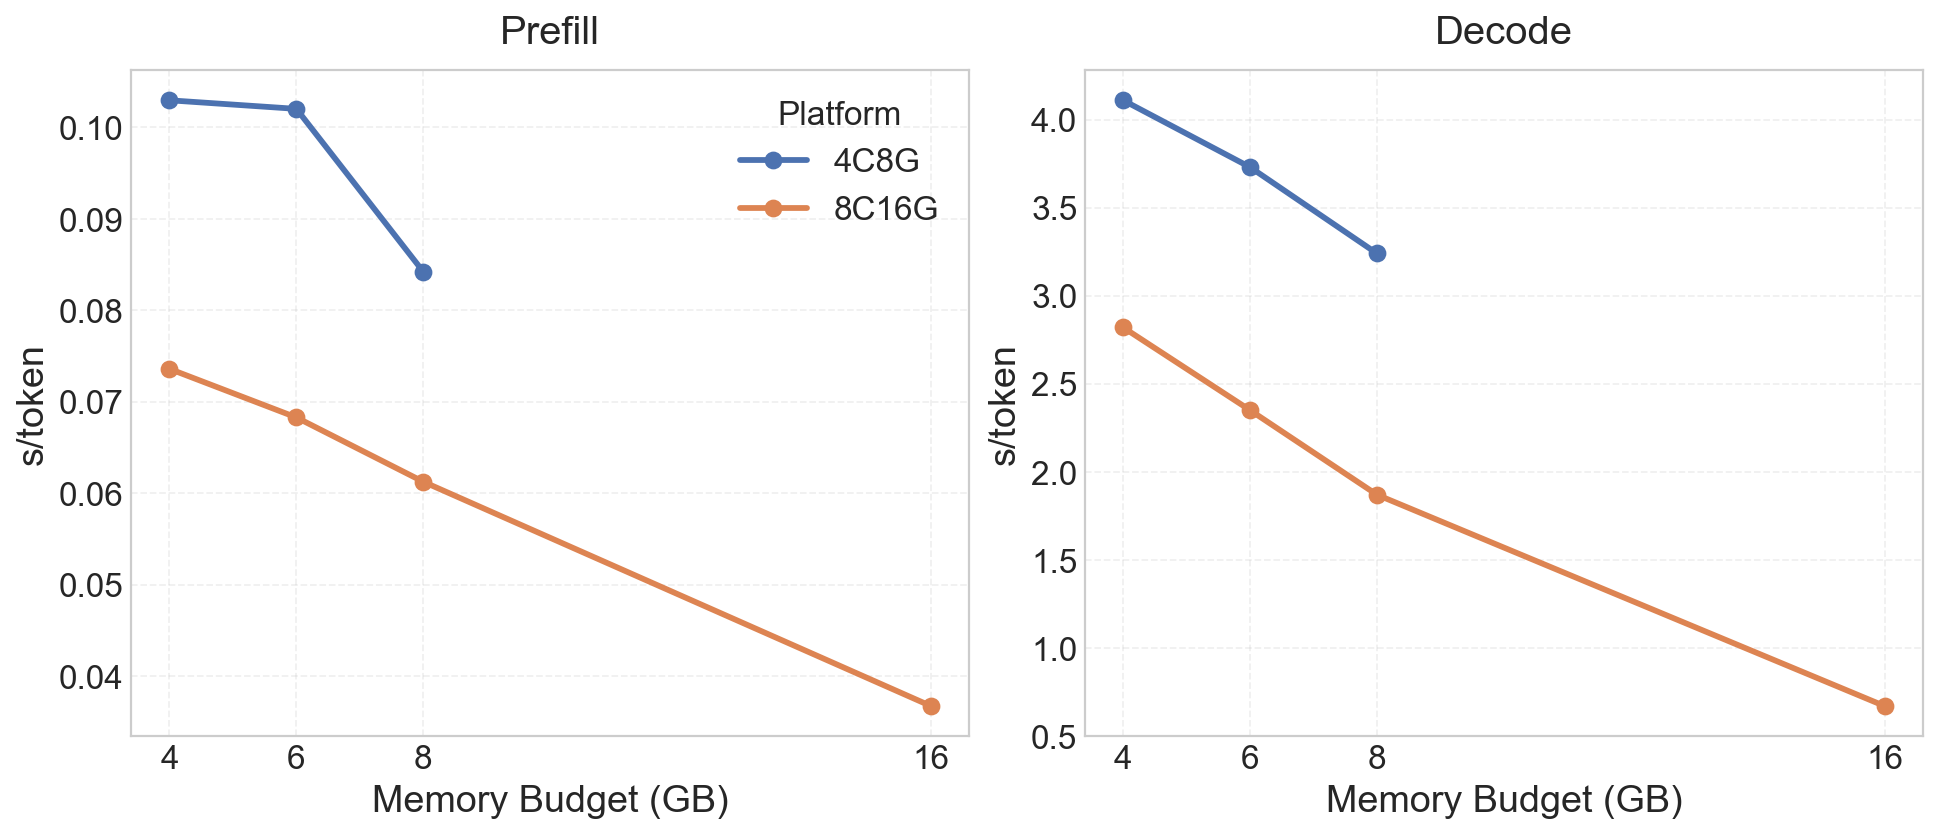

Saved figure to /Users/sunweber/workspace/dist_learn/KVTensor/evaluation/figures/section63_figure2.pdf


In [8]:
# Section 6.3.2: memory budget figure
apply_plot_style()

if "repo_root" not in globals():
    def find_repo_root() -> Path:
        for root in (Path.cwd(), *Path.cwd().parents):
            if (root / "evaluation" / "section63_figure2.csv").exists():
                return root
        raise FileNotFoundError("Could not locate the repository root from the current working directory.")

    repo_root = find_repo_root()

memory_df = pd.read_csv(repo_root / "evaluation" / "section63_figure2.csv")
memory_df["prefill_per_token_s"] = memory_df["prefill_s"] / 64.0
memory_df["decode_per_token_s"] = memory_df["decode_s"]
memory_df = memory_df.sort_values(["platform", "memory_budget_gb"])

platform_order = ["4c8g", "8c16g"]
platform_labels = {"4c8g": "4C8G", "8c16g": "8C16G"}
platform_colors = {"4c8g": "#4C72B0", "8c16g": "#DD8452"}

fig, axes = plt.subplots(1, 2, figsize=(12.0, 5.1), constrained_layout=True)

for ax, metric, title in zip(
    axes,
    ["prefill_per_token_s", "decode_per_token_s"],
    ["Prefill", "Decode"],
):
    for platform in platform_order:
        platform_df = memory_df.loc[memory_df["platform"] == platform].sort_values("memory_budget_gb")
        ax.plot(
            platform_df["memory_budget_gb"],
            platform_df[metric],
            marker="o",
            linewidth=2.6,
            markersize=7,
            color=platform_colors[platform],
            label=platform_labels[platform],
        )
    ax.set_title(title)
    ax.set_xlabel("Memory Budget (GB)")
    ax.set_ylabel("s/token")
    ax.set_xticks(sorted(memory_df["memory_budget_gb"].unique()))
    ax.grid(True, linestyle="--", alpha=0.3)
    ax.set_axisbelow(True)

axes[0].legend(title="Platform", frameon=False)

output_path = repo_root / "evaluation" / "figures" / "section63_figure2.pdf"
fig.savefig(output_path, bbox_inches="tight")
plt.show()
print(f"Saved figure to {output_path}")


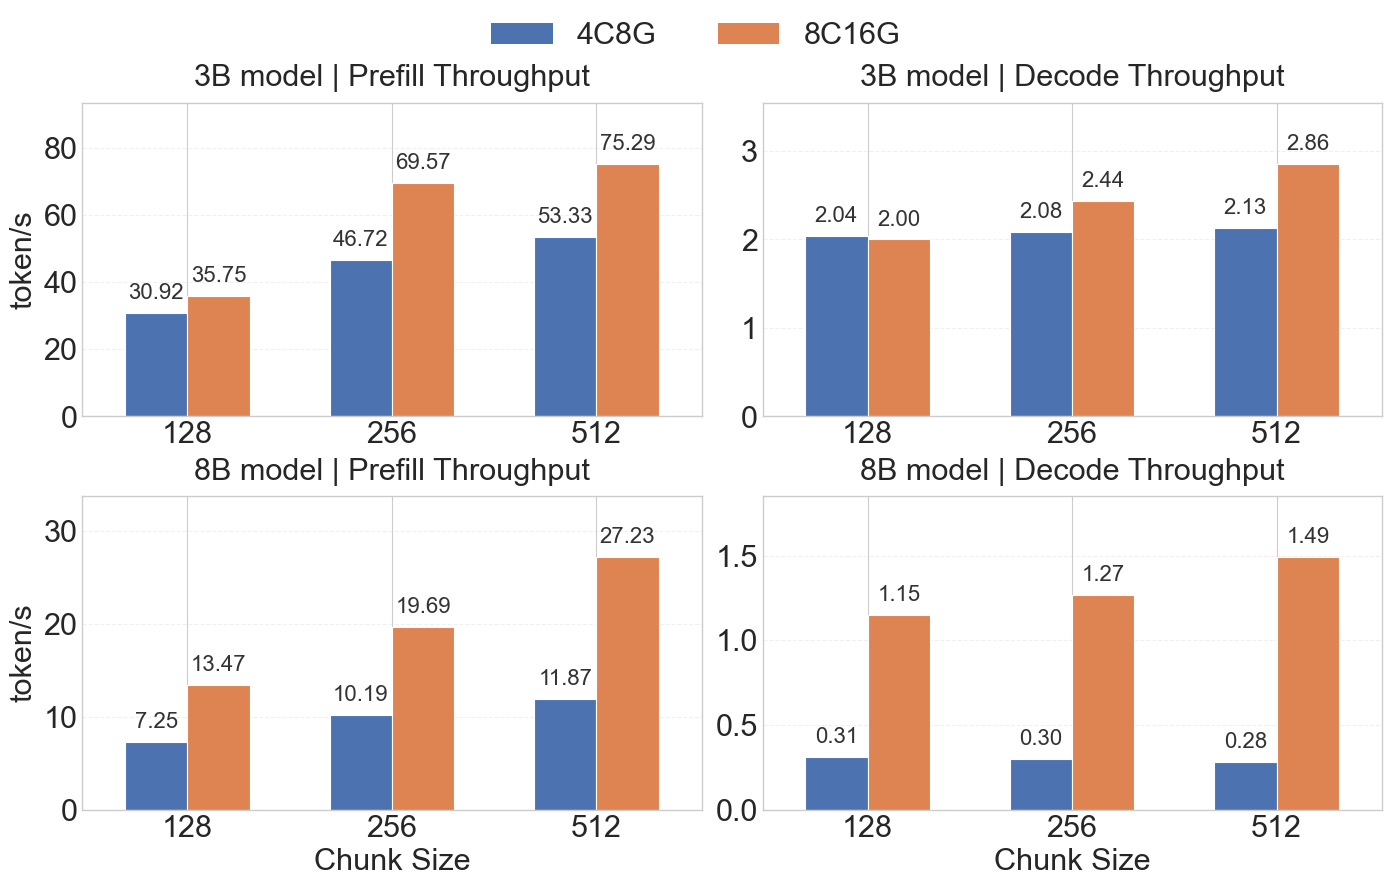

Saved figure to /Users/sunweber/workspace/dist_learn/KVTensor/evaluation/figures/section63_figure3.pdf


In [31]:
# Section 6.3.3: chunk size figure
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

apply_plot_style()

if "repo_root" not in globals():
    def find_repo_root() -> Path:
        for root in (Path.cwd(), *Path.cwd().parents):
            if (root / "evaluation" / "section63_figure3.csv").exists():
                return root
        raise FileNotFoundError("Could not locate the repository root from the current working directory.")

    repo_root = find_repo_root()

chunk_df = pd.read_csv(repo_root / "evaluation" / "section63_figure3.csv")
chunk_df["model"] = chunk_df["model"].str.lower()
chunk_df["prefill_token_per_s"] = 64.0 / chunk_df["prefill_s"]
chunk_df["decode_token_per_s"] = 1.0 / chunk_df["decode_s"]
chunk_df = chunk_df.sort_values(["model", "platform", "chunk_size"])

model_order = ["3b", "8b"]
model_labels = {"3b": "3B model", "8b": "8B model"}
platform_order = ["4c8g", "8c16g"]
platform_labels = {"4c8g": "4C8G", "8c16g": "8C16G"}
platform_colors = {"4c8g": "#4C72B0", "8c16g": "#DD8452"}
chunk_order = [128, 256, 512]
metric_specs = [
    ("prefill_token_per_s", "Prefill Throughput"),
    ("decode_token_per_s", "Decode Throughput"),
]

x_positions = [0.0, 1.05, 2.10]
width = 0.32
offsets = [-0.5 * width, 0.5 * width]


def format_metric_label(value: float) -> str:
    return f"{value:.2f}" if value < 100 else f"{value:.1f}"


def plot_chunk_panel(ax, panel_df, metric, title):
    panel_max = float(panel_df[metric].max())
    label_pad = panel_max * 0.04

    for offset, platform in zip(offsets, platform_order):
        platform_df = panel_df.loc[panel_df["platform"] == platform].set_index("chunk_size")
        xs = []
        ys = []
        for x, chunk_size in zip(x_positions, chunk_order):
            if chunk_size in platform_df.index:
                xs.append(x + offset)
                ys.append(float(platform_df.at[chunk_size, metric]))

        bars = ax.bar(
            xs,
            ys,
            width=width,
            color=platform_colors[platform],
            edgecolor="white",
            linewidth=0.8,
        )

        for bar, value in zip(bars, ys):
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                value + label_pad,
                format_metric_label(value),
                ha="center",
                va="bottom",
                fontsize=16,
                color="#333333",
                clip_on=False,
            )

    ax.set_ylim(0, panel_max * 1.24)
    ax.set_xticks(x_positions)
    ax.set_xticklabels(chunk_order)
    ax.set_title(title, fontsize=22)
    ax.margins(x=0.08)
    ax.grid(axis="y", linestyle="--", alpha=0.28)
    ax.set_axisbelow(True)

fig, axes = plt.subplots(2, 2, figsize=(13.8, 8.2), constrained_layout=True)

for row_idx, model in enumerate(model_order):
    model_df = chunk_df.loc[chunk_df["model"] == model].copy()
    for col_idx, (metric, metric_title) in enumerate(metric_specs):
        ax = axes[row_idx, col_idx]
        plot_chunk_panel(ax, model_df, metric, f"{model_labels[model]} | {metric_title}")
        if row_idx == len(model_order) - 1:
            ax.set_xlabel("Chunk Size")
        if col_idx == 0:
            ax.set_ylabel("token/s")

legend_handles = [Patch(facecolor=platform_colors[p], label=platform_labels[p]) for p in platform_order]
fig.legend(
    legend_handles,
    [handle.get_label() for handle in legend_handles],
    loc="upper center",
    ncol=len(legend_handles),
    frameon=False,
    bbox_to_anchor=(0.5, 1.08),
)

output_dir = repo_root / "evaluation" / "figures"
output_dir.mkdir(parents=True, exist_ok=True)
pdf_path = output_dir / "section63_figure3.pdf"
fig.savefig(pdf_path, bbox_inches="tight")
plt.show()
print(f"Saved figure to {pdf_path}")


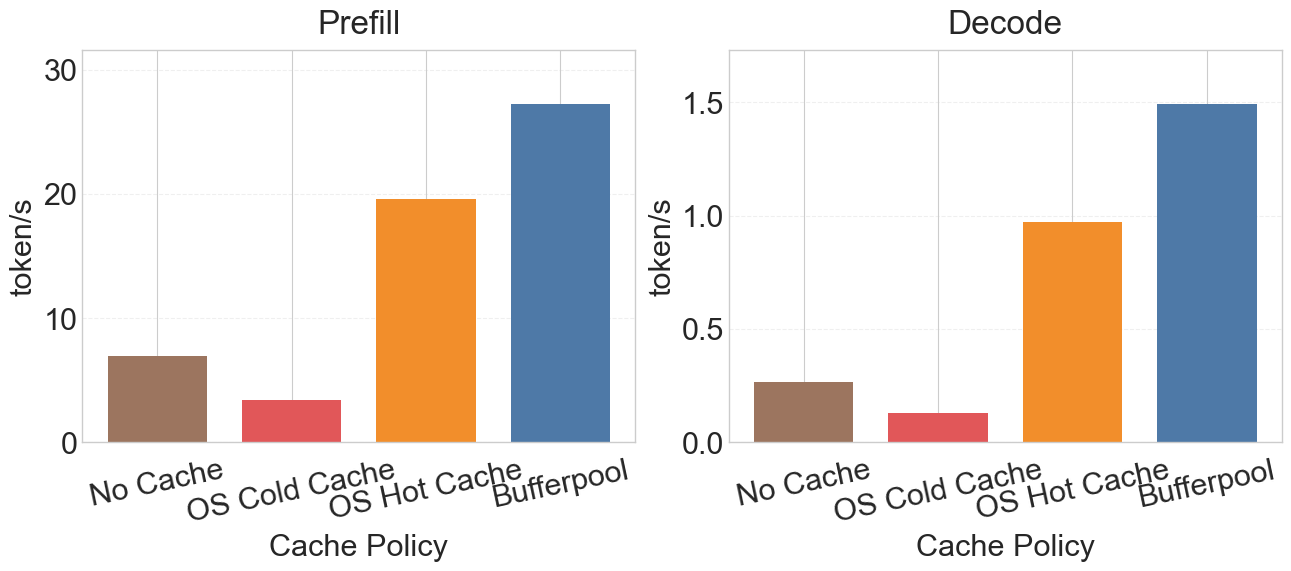

Saved figure to /Users/sunweber/workspace/dist_learn/KVTensor/evaluation/figures/section63_figure4.pdf


In [32]:
# Section 6.3.4: cache policy figure
apply_plot_style()

if "repo_root" not in globals():
    def find_repo_root() -> Path:
        for root in (Path.cwd(), *Path.cwd().parents):
            if (root / "evaluation" / "section63_figure4.csv").exists():
                return root
        raise FileNotFoundError("Could not locate the repository root from the current working directory.")

    repo_root = find_repo_root()

cache_df = pd.read_csv(repo_root / "evaluation" / "section63_figure4.csv")
cache_df["prefill_token_per_s"] = 64.0 / cache_df["prefill_s"]
cache_df["decode_token_per_s"] = 1.0 / cache_df["decode_s"]

policy_order = [
    "no cache",
    "os page cache (cold)",
    "os page cache (hot)",
    "bufferpool",
]
policy_labels = {
    "no cache": "No Cache",
    "os page cache (cold)": "OS Cold Cache",
    "os page cache (hot)": "OS Hot Cache",
    "bufferpool": "Bufferpool",
}
policy_colors = {
    "no cache": "#9C755F",
    "os page cache (cold)": "#E15759",
    "os page cache (hot)": "#F28E2B",
    "bufferpool": "#4E79A7",
}
cache_df["cache_policy"] = pd.Categorical(cache_df["cache_policy"], categories=policy_order, ordered=True)
cache_df = cache_df.sort_values("cache_policy")

fig, axes = plt.subplots(1, 2, figsize=(12.8, 5.6), constrained_layout=True)
x_positions = list(range(len(policy_order)))
bar_colors = [policy_colors[p] for p in cache_df["cache_policy"]]

for ax, metric, title in zip(
    axes,
    ["prefill_token_per_s", "decode_token_per_s"],
    ["Prefill", "Decode"],
):
    ax.bar(x_positions, cache_df[metric], color=bar_colors, width=0.74)
    ax.set_title(title)
    ax.set_xlabel("Cache Policy")
    ax.set_ylabel("token/s")
    ax.set_xticks(x_positions)
    ax.set_xticklabels([policy_labels[p] for p in cache_df["cache_policy"]], rotation=12)
    ax.tick_params(axis="x", pad=10)
    ax.grid(axis="y", linestyle="--", alpha=0.3)
    ax.set_axisbelow(True)
    ax.set_ylim(0, float(cache_df[metric].max()) * 1.16)

output_path = repo_root / "evaluation" / "figures" / "section63_figure4.pdf"
output_path.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(output_path, bbox_inches="tight")
plt.show()
print(f"Saved figure to {output_path}")


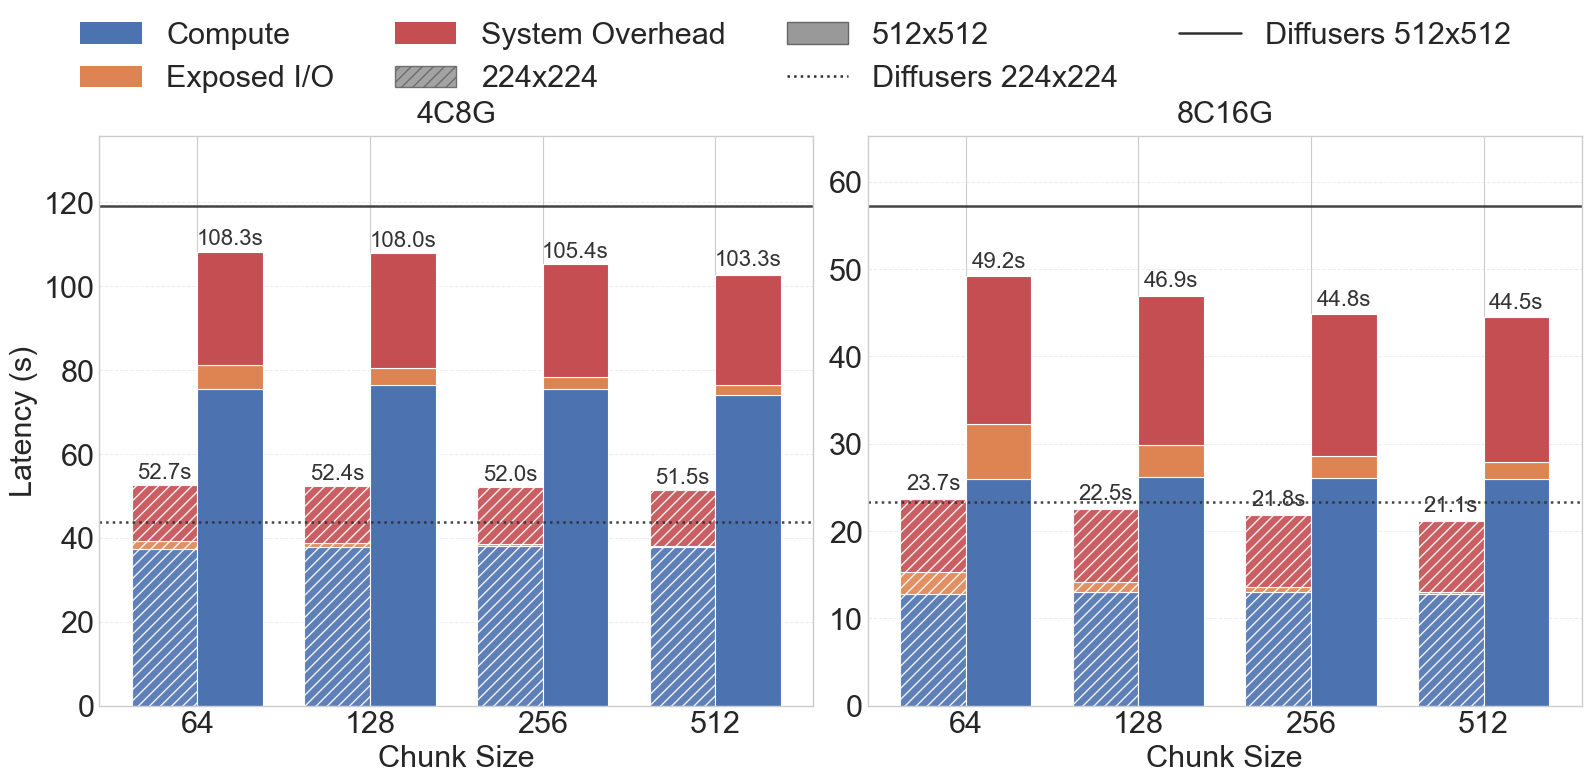

Saved figure to /Users/sunweber/workspace/dist_learn/KVTensor/evaluation/figures/diffusion_runtime_breakdown.pdf


In [36]:
# Diffusion model: runtime breakdown across chunk sizes, image sizes, and platforms
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

apply_plot_style()

if "repo_root" not in globals():
    def find_repo_root() -> Path:
        for root in (Path.cwd(), *Path.cwd().parents):
            if (root / "evaluation" / "diffusion.csv").exists():
                return root
        raise FileNotFoundError("Could not locate the repository root from the current working directory.")

    repo_root = find_repo_root()


diffusion_df = pd.read_csv(repo_root / "evaluation" / "diffusion.csv")

numeric_columns = [column for column in diffusion_df.columns if column != "platform_id"]
for column in numeric_columns:
    diffusion_df[column] = pd.to_numeric(diffusion_df[column], errors="coerce")

diffusion_df["profiled_compute_s"] = (
    diffusion_df["median_profiled_compute_ms"]
    + diffusion_df["median_profiled_other_compute_ms"]
    + diffusion_df["median_profiled_decompress_ms"]
) / 1000.0
diffusion_df["exposed_io_s"] = (
    diffusion_df["median_profiled_io_ms"]
    + diffusion_df["median_unprofiled_pipeline_ms"]
) / 1000.0
diffusion_df["system_overhead_s"] = (
    diffusion_df["median_profiled_system_overhead_ms"]
    + diffusion_df["median_prefetch_warmup_ms"]
) / 1000.0
diffusion_df["execution_s"] = diffusion_df["median_execution_ms_excluding_preload"] / 1000.0

platform_order = ["4c8g", "8c16g"]
platform_labels = {"4c8g": "4C8G", "8c16g": "8C16G"}
img_order = [224, 512]
img_labels = {224: "224x224", 512: "512x512"}
diffusers_baseline_s = {
    "4c8g": {224: 43.7, 512: 119.1},
    "8c16g": {224: 23.3, 512: 57.2},
}
chunk_order = [64, 128, 256, 512]

component_specs = [
    ("profiled_compute_s", "Compute", "#4C72B0"),
    ("exposed_io_s", "Exposed I/O", "#DD8452"),
    ("system_overhead_s", "System Overhead", "#C44E52"),
]
img_style = {
    224: {"hatch": "///", "alpha": 0.9},
    512: {"hatch": None, "alpha": 1.0},
}

fig, axes = plt.subplots(1, len(platform_order), figsize=(15.8, 6.8), sharey=False, constrained_layout=True)
if len(platform_order) == 1:
    axes = [axes]

x = np.arange(len(chunk_order))
bar_width = 0.38
offsets = {224: -bar_width / 2, 512: bar_width / 2}

for ax, platform_id in zip(axes, platform_order):
    platform_df = diffusion_df.loc[diffusion_df["platform_id"] == platform_id].copy()

    panel_max = 0.0
    for img_size in img_order:
        subset = platform_df.loc[platform_df["img_size"] == img_size].set_index("chunk_size").reindex(chunk_order)
        bottom = np.zeros(len(chunk_order), dtype=float)
        style = img_style[img_size]
        centers = x + offsets[img_size]

        for column, _, color in component_specs:
            values = subset[column].fillna(0.0).to_numpy(dtype=float)
            ax.bar(
                centers,
                values,
                width=bar_width,
                bottom=bottom,
                color=color,
                hatch=style["hatch"],
                alpha=style["alpha"],
                edgecolor="white",
                linewidth=0.8,
            )
            bottom += values

        execution_values = subset["execution_s"].fillna(0.0).to_numpy(dtype=float)
        panel_max = max(panel_max, float(np.nanmax(execution_values)))
        for center, total in zip(centers, execution_values):
            ax.text(
                center,
                total + 0.6,
                f"{total:.1f}s",
                ha="center",
                va="bottom",
                fontsize=16,
                color="#333333",
            )

    for img_size in img_order:
        baseline_value = diffusers_baseline_s[platform_id][img_size]
        panel_max = max(panel_max, baseline_value)
        ax.axhline(
            baseline_value,
            color="#2F2F2F",
            linestyle=":" if img_size == 224 else "-",
            linewidth=1.8,
            alpha=0.9,
        )

    ax.set_title(platform_labels[platform_id], fontsize=22, pad=10)
    ax.set_xticks(x, [str(chunk) for chunk in chunk_order])
    ax.set_xlabel("Chunk Size")
    ax.grid(axis="y", linestyle="--", linewidth=0.7, alpha=0.35)
    ax.set_axisbelow(True)
    ax.set_ylim(0, panel_max * 1.14)

axes[0].set_ylabel("Latency (s)")

component_handles = [Patch(facecolor=color, label=label) for _, label, color in component_specs]
image_handles = [
    Patch(facecolor="#999999", edgecolor="#666666", hatch=img_style[size]["hatch"], alpha=img_style[size]["alpha"], label=img_labels[size])
    for size in img_order
]
baseline_handles = [
    Line2D([0], [0], color="#2F2F2F", linestyle=":" if size == 224 else "-", linewidth=1.8, label=f"Diffusers {img_labels[size]}")
    for size in img_order
]
fig.legend(
    handles=component_handles + image_handles + baseline_handles,
    loc="upper center",
    ncol=4,
    frameon=False,
    bbox_to_anchor=(0.5, 1.15),
)

output_dir = repo_root / "evaluation" / "figures"
output_dir.mkdir(parents=True, exist_ok=True)
pdf_path = output_dir / "diffusion_runtime_breakdown.pdf"
fig.savefig(pdf_path, bbox_inches="tight")

plt.show()
print(f"Saved figure to {pdf_path}")
